<a href="https://colab.research.google.com/github/merls0515/hotel-booking-analysis/blob/main/Hotel_Booking_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**HOTEL BOOKING PERFORMANCE ANALYSIS**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Hotel_bookings_final.csv')

df.head()

df.info()

df.isnull().sum()

df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non-null  object 
 16  refu

['customer_id',
 'property_id',
 'city',
 'star_rating',
 'booking_date',
 'check_in_date',
 'check_out_date',
 'room_type',
 'num_rooms_booked',
 'stay_type',
 'booking_channel',
 'booking_value',
 'costprice',
 'markup',
 'selling_price',
 'payment_method',
 'refund_status',
 'refund_amount',
 'channel_of_booking',
 'booking_status',
 'travel_date',
 'cashback',
 'coupon_redeem',
 'Coupon USed?']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Hotel_bookings_final.csv')

df['booking_date'] = pd.to_datetime(df['booking_date'], format='%d-%m-%Y')
df['check_in_date'] = pd.to_datetime(df['check_in_date'], format='%d-%m-%Y')
df['check_out_date'] = pd.to_datetime(df['check_out_date'], format='%d-%m-%Y')
df['travel_date'] = pd.to_datetime(df['travel_date'], format='%d-%m-%Y')

# ========== BUSINESS METRICS ==========

# 2. Stay Length (days)
df['stay_length'] = (df['check_out_date'] - df['check_in_date']).dt.days

# 3. Lead Time (days between booking and check-in)
df['lead_time'] = (df['check_in_date'] - df['booking_date']).dt.days

# 4. Booking Month (for seasonality)
df['booking_month'] = df['booking_date'].dt.month
df['booking_month_name'] = df['booking_date'].dt.month_name()

# 5. Revenue Lost due to Cancellations
df['revenue_lost'] = np.where(df['booking_status'] == 'Cancelled', df['booking_value'], 0)

# 6. Profit Margin
df['profit_margin'] = ((df['selling_price'] - df['costprice']) / df['selling_price']) * 100

# 7. Cancellation Flag
df['is_cancelled'] = (df['booking_status'] == 'Cancelled').astype(int)

# ========== VERIFY METRICS CREATED ==========
print("✅ Business Metrics Created Successfully!")
print(f"Stay Length - Min: {df['stay_length'].min()}, Max: {df['stay_length'].max()}, Mean: {df['stay_length'].mean():.1f}")
print(f"Lead Time - Min: {df['lead_time'].min()}, Max: {df['lead_time'].max()}, Mean: {df['lead_time'].mean():.1f}")
print(f"Booking Months: {sorted(df['booking_month'].unique())}")
print(f"Revenue Lost from Cancellations: ${df['revenue_lost'].sum():,.2f}")
print(f"Overall Cancellation Rate: {df['is_cancelled'].mean() * 100:.2f}%")

# Show first 5 rows with new metrics
df[['booking_date', 'check_in_date', 'stay_length', 'lead_time', 'booking_month',
    'booking_value', 'is_cancelled', 'revenue_lost']].head()

✅ Business Metrics Created Successfully!
Stay Length - Min: 1.0, Max: 7.0, Mean: 4.0
Lead Time - Min: 1.0, Max: 60.0, Mean: 30.4
Booking Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Revenue Lost from Cancellations: $146,834,852.69
Overall Cancellation Rate: 20.23%


,booking_date,check_in_date,stay_length,lead_time,booking_month,booking_value,is_cancelled,revenue_lost
0,2024-04-01,2024-05-24,2.0,53.0,4,19361.0,0,0.0
1,2024-04-01,2024-05-10,7.0,39.0,4,6137.0,0,0.0
2,2024-04-01,2024-05-31,5.0,60.0,4,22702.0,0,0.0
3,2024-04-01,2024-04-18,6.0,17.0,4,34068.0,0,0.0
4,2024-04-01,NaT,NaN,NaN,4,12127.0,1,12127.0


In [ ]:
# checking for outliers in metrics

print("="*50)
print("OUTLIER CHECK")
print("="*50)

# Check for negative or zero stay length
print(f"Stay Length <= 0: {(df['stay_length'] <= 0).sum()} rows")
print(f"Lead Time < 0: {(df['lead_time'] < 0).sum()} rows")
print(f"Lead Time = 0: {(df['lead_time'] == 0).sum()} rows")

# Filter out invalid records if needed (optional - run only if issues found)
# df_clean = df[(df['stay_length'] > 0) & (df['lead_time'] >= 0)]

# Summary statistics
print("\n📊 Stay Length Distribution (days):")
print(df['stay_length'].describe())

print("\n📊 Lead Time Distribution (days):")
print(df['lead_time'].describe())

print("\n📊 Profit Margin Distribution (%):")
print(df['profit_margin'].describe())

OUTLIER CHECK
Stay Length <= 0: 0 rows
Lead Time < 0: 0 rows
Lead Time = 0: 0 rows

📊 Stay Length Distribution (days):
count    24532.000000
mean         4.006848
std          2.001231
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max          7.000000
Name: stay_length, dtype: float64

📊 Lead Time Distribution (days):
count    24532.000000
mean        30.378485
std         17.374172
min          1.000000
25%         15.000000
50%         30.000000
75%         45.000000
max         60.000000
Name: lead_time, dtype: float64

📊 Profit Margin Distribution (%):
count    30000.000000
mean        23.601144
std          0.002146
min         23.598945
25%         23.599798
50%         23.600626
75%         23.601690
max         23.618189
Name: profit_margin, dtype: float64


REVENUE & PROFITABILITY BY CHANNEL, ROOM TYPE & STAR RATING

📊 CHANNEL ANALYSIS
                 total_bookings  total_revenue  avg_booking_value  \
booking_channel                                                     
Web                       15001      443990337           29597.38   
Mobile App                12009      353334888           29422.51   
Travel Agent               2990       87819330           29371.01   

                 total_profit  avg_profit_per_booking  cancellation_rate  
booking_channel                                                           
Web                 104784520                 6985.17               18.0  
Mobile App           83389308                 6943.90               22.0  
Travel Agent         20725904                 6931.74               28.0  

🏨 ROOM TYPE ANALYSIS
           total_bookings  total_revenue  avg_booking_value  total_profit  \
room_type                                                                   
Standard            165

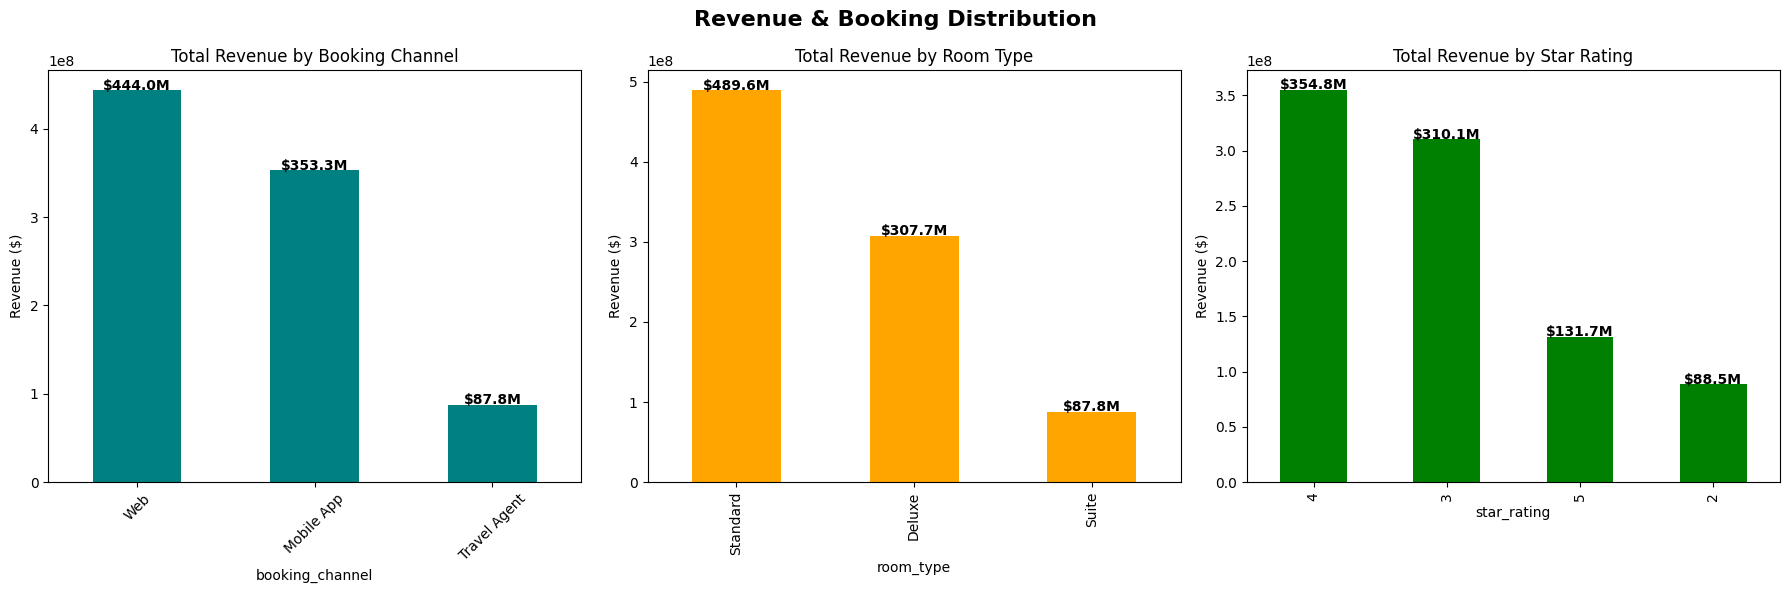


✅ Revenue analysis complete. Chart saved as 'revenue_analysis.png'


In [ ]:
# REVENUE & PROFITABILITY ANALYSIS (Missing piece)

print("="*60)
print("REVENUE & PROFITABILITY BY CHANNEL, ROOM TYPE & STAR RATING")
print("="*60)

# 1. Channel Analysis
print("\n📊 CHANNEL ANALYSIS")
channel_revenue = df.groupby('booking_channel').agg(
    total_bookings=('customer_id', 'count'),
    total_revenue=('selling_price', 'sum'),
    avg_booking_value=('selling_price', 'mean'),
    total_profit=('markup', 'sum'),
    avg_profit_per_booking=('markup', 'mean'),
    cancellation_rate=('is_cancelled', 'mean')
).round(2)
channel_revenue['cancellation_rate'] = channel_revenue['cancellation_rate'] * 100
channel_revenue = channel_revenue.sort_values('total_revenue', ascending=False)
print(channel_revenue)

# 2. Room Type Analysis
print("\n🏨 ROOM TYPE ANALYSIS")
room_revenue = df.groupby('room_type').agg(
    total_bookings=('customer_id', 'count'),
    total_revenue=('selling_price', 'sum'),
    avg_booking_value=('selling_price', 'mean'),
    total_profit=('markup', 'sum'),
    avg_profit_per_booking=('markup', 'mean'),
    cancellation_rate=('is_cancelled', 'mean')
).round(2)
room_revenue['cancellation_rate'] = room_revenue['cancellation_rate'] * 100
room_revenue = room_revenue.sort_values('total_revenue', ascending=False)
print(room_revenue)

# 3. Star Rating Analysis
print("\n⭐ STAR RATING ANALYSIS")
star_revenue = df.groupby('star_rating').agg(
    total_bookings=('customer_id', 'count'),
    total_revenue=('selling_price', 'sum'),
    avg_booking_value=('selling_price', 'mean'),
    total_profit=('markup', 'sum'),
    avg_profit_per_booking=('markup', 'mean'),
    cancellation_rate=('is_cancelled', 'mean')
).round(2)
star_revenue['cancellation_rate'] = star_revenue['cancellation_rate'] * 100
star_revenue = star_revenue.sort_values('total_revenue', ascending=False)
print(star_revenue)

# 4. Visualizations for PPT
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Revenue & Booking Distribution', fontsize=16, fontweight='bold')

# Revenue by Channel
channel_revenue['total_revenue'].plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Total Revenue by Booking Channel')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(channel_revenue['total_revenue']):
    axes[0].text(i, v + 500000, f'${v/1e6:.1f}M', ha='center', fontweight='bold')

# Revenue by Room Type
room_revenue['total_revenue'].plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Total Revenue by Room Type')
axes[1].set_ylabel('Revenue ($)')
for i, v in enumerate(room_revenue['total_revenue']):
    axes[1].text(i, v + 500000, f'${v/1e6:.1f}M', ha='center', fontweight='bold')

# Revenue by Star Rating
star_revenue['total_revenue'].plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Total Revenue by Star Rating')
axes[2].set_ylabel('Revenue ($)')
for i, v in enumerate(star_revenue['total_revenue']):
    axes[2].text(i, v + 500000, f'${v/1e6:.1f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('revenue_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Revenue analysis complete. Chart saved as 'revenue_analysis.png'")

ROOT CAUSE ANALYSIS: Cancellation Patterns

1️⃣ LEAD TIME IMPACT ON CANCELLATIONS
Avg Lead Time - Completed: 30.4 days
Avg Lead Time - Cancelled: 30.2 days
Difference: -0.2 days longer for cancellations

2️⃣ STAY LENGTH IMPACT ON CANCELLATIONS
Avg Stay Length - Completed: 4.0 days
Avg Stay Length - Cancelled: 4.0 days

3️⃣ BOOKING VALUE IMPACT ON CANCELLATIONS
Avg Booking Value - Completed: $25,306
Avg Booking Value - Cancelled: $24,190
Difference: $-1,116 higher for cancellations

4️⃣ SEASONAL PATTERN - Cancellations by Month
booking_month_name
January      23.686441
February     17.495310
March        17.584746
April        16.310636
May          17.288136
June         17.513135
July         30.326133
August       28.771186
September    17.732049
October      17.372881
November     15.929978
December     25.762712
Name: is_cancelled, dtype: float64

5️⃣ PAYMENT METHOD IMPACT ON CANCELLATIONS
payment_method
PayPal           20.806962
Credit Card      20.568607
Debit Card       20.3472

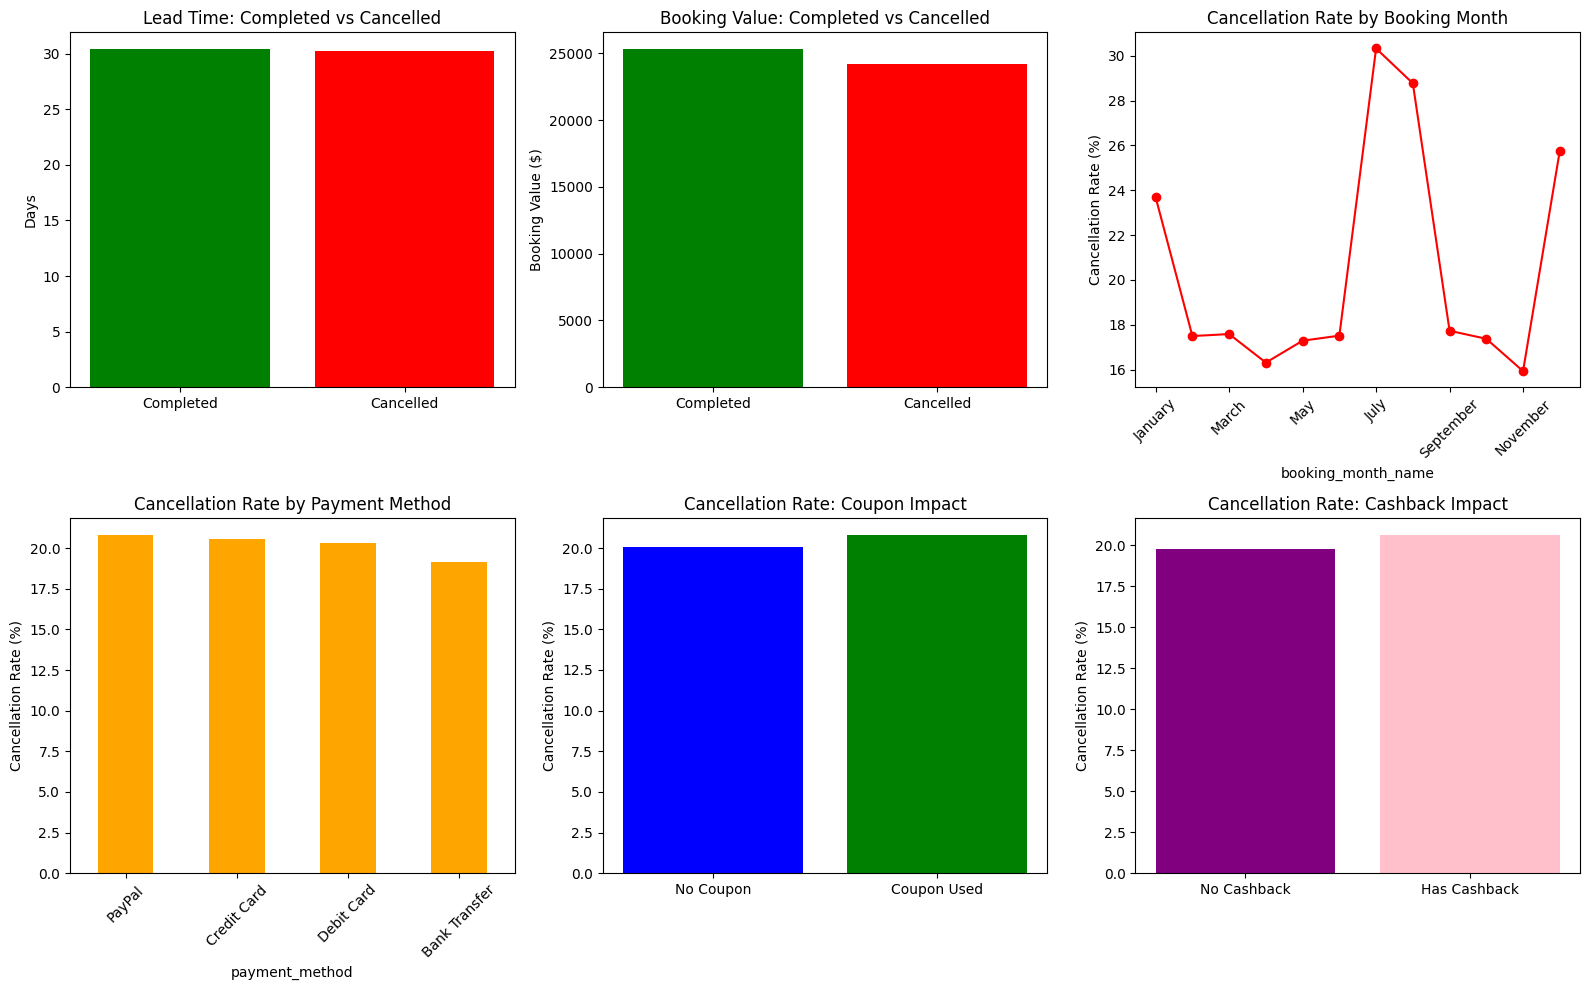


📊 SUMMARY: Top Factors Driving Cancellations
• Lead Time Difference: -0.2 days longer for cancellations
• Booking Value Difference: $-1,116 higher for cancellations
• Highest Cancellation Channel: Travel Agent (27.9%)
• Highest Cancellation Room: Standard (23.3%)
• Highest Cancellation Star Rating: 5 stars (21.3%)
• Highest Cancellation Payment Method: PayPal (20.8%)
• Coupon Users Cancellation Rate: 20.8%
• Refundable Bookings Cancellation Rate: 20.6%

📊 BONUS: Coupon Redeem Value Analysis
Avg Coupon Redeem for Cancelled: $4.19
Avg Coupon Redeem for Completed: $4.12

✅ Cancellation analysis complete. Chart saved as 'cancellation_analysis_chart.png'


In [ ]:
# Root Cause Analysis - Why do cancellations happen? (FULLY FIXED)

print("="*60)
print("ROOT CAUSE ANALYSIS: Cancellation Patterns")
print("="*60)

# 1. Lead Time Analysis
print("\n1️⃣ LEAD TIME IMPACT ON CANCELLATIONS")
lead_time_cancel = df.groupby('is_cancelled')['lead_time'].mean()
print(f"Avg Lead Time - Completed: {lead_time_cancel[0]:.1f} days")
print(f"Avg Lead Time - Cancelled: {lead_time_cancel[1]:.1f} days")
print(f"Difference: {lead_time_cancel[1] - lead_time_cancel[0]:.1f} days longer for cancellations")

# 2. Stay Length Analysis
print("\n2️⃣ STAY LENGTH IMPACT ON CANCELLATIONS")
stay_cancel = df.groupby('is_cancelled')['stay_length'].mean()
print(f"Avg Stay Length - Completed: {stay_cancel[0]:.1f} days")
print(f"Avg Stay Length - Cancelled: {stay_cancel[1]:.1f} days")

# 3. Booking Value Analysis
print("\n3️⃣ BOOKING VALUE IMPACT ON CANCELLATIONS")
value_cancel = df.groupby('is_cancelled')['booking_value'].mean()
print(f"Avg Booking Value - Completed: ${value_cancel[0]:,.0f}")
print(f"Avg Booking Value - Cancelled: ${value_cancel[1]:,.0f}")
print(f"Difference: ${value_cancel[1] - value_cancel[0]:,.0f} higher for cancellations")

# 4. Seasonal Pattern
print("\n4️⃣ SEASONAL PATTERN - Cancellations by Month")
monthly_cancel = df.groupby('booking_month_name')['is_cancelled'].mean() * 100
monthly_cancel = monthly_cancel.reindex(['January', 'February', 'March', 'April', 'May', 'June',
                                          'July', 'August', 'September', 'October', 'November', 'December'])
print(monthly_cancel)

# 5. Payment Method Impact
print("\n5️⃣ PAYMENT METHOD IMPACT ON CANCELLATIONS")
payment_cancel = df.groupby('payment_method')['is_cancelled'].mean().sort_values(ascending=False) * 100
print(payment_cancel)

# 6. Coupon Usage Impact (FIXED - using correct column name from your screenshot)
print("\n6️⃣ COUPON IMPACT ON CANCELLATIONS")
coupon_cancel = df.groupby('Coupon USed?')['is_cancelled'].mean() * 100
print(f"Coupon NOT Used: {coupon_cancel.get('No', 0):.2f}% cancellation")
print(f"Coupon Used: {coupon_cancel.get('Yes', 0):.2f}% cancellation")

# 7. Cashback Impact
print("\n7️⃣ CASHBACK IMPACT ON CANCELLATIONS")
df['has_cashback'] = (df['cashback'] > 0).astype(int)
cashback_cancel = df.groupby('has_cashback')['is_cancelled'].mean() * 100
print(f"No Cashback: {cashback_cancel[0]:.2f}% cancellation")
print(f"Has Cashback: {cashback_cancel[1]:.2f}% cancellation")

# 8. Refund Impact
print("\n8️⃣ REFUND IMPACT ON CANCELLATIONS")
refund_cancel = df.groupby('refund_status')['is_cancelled'].mean().sort_values(ascending=False) * 100
print(refund_cancel)

# 9. VISUALIZATIONS
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Lead Time Comparison
lead_data = [lead_time_cancel[0], lead_time_cancel[1]]
axes[0,0].bar(['Completed', 'Cancelled'], lead_data, color=['green', 'red'])
axes[0,0].set_title('Lead Time: Completed vs Cancelled')
axes[0,0].set_ylabel('Days')

# Booking Value Comparison
value_data = [value_cancel[0], value_cancel[1]]
axes[0,1].bar(['Completed', 'Cancelled'], value_data, color=['green', 'red'])
axes[0,1].set_title('Booking Value: Completed vs Cancelled')
axes[0,1].set_ylabel('Booking Value ($)')

# Monthly Cancellation Rate
monthly_cancel.plot(kind='line', marker='o', ax=axes[0,2], color='red')
axes[0,2].set_title('Cancellation Rate by Booking Month')
axes[0,2].set_ylabel('Cancellation Rate (%)')
axes[0,2].tick_params(axis='x', rotation=45)

# Payment Method
payment_cancel.plot(kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('Cancellation Rate by Payment Method')
axes[1,0].set_ylabel('Cancellation Rate (%)')
axes[1,0].tick_params(axis='x', rotation=45)

# Coupon Impact (FIXED)
coupon_data = [coupon_cancel.get('No', 0), coupon_cancel.get('Yes', 0)]
axes[1,1].bar(['No Coupon', 'Coupon Used'], coupon_data, color=['blue', 'green'])
axes[1,1].set_title('Cancellation Rate: Coupon Impact')
axes[1,1].set_ylabel('Cancellation Rate (%)')

# Cashback Impact
cashback_data = [cashback_cancel[0], cashback_cancel[1]]
axes[1,2].bar(['No Cashback', 'Has Cashback'], cashback_data, color=['purple', 'pink'])
axes[1,2].set_title('Cancellation Rate: Cashback Impact')
axes[1,2].set_ylabel('Cancellation Rate (%)')

plt.tight_layout()
plt.show()

# 10. SUMMARY OF ROOT CAUSES
print("\n" + "="*60)
print("📊 SUMMARY: Top Factors Driving Cancellations")
print("="*60)

# Re-calculate channel, room, star
channel_cancel = df.groupby('booking_channel')['is_cancelled'].mean().sort_values(ascending=False) * 100
room_cancel = df.groupby('room_type')['is_cancelled'].mean().sort_values(ascending=False) * 100
star_cancel = df.groupby('star_rating')['is_cancelled'].mean().sort_values(ascending=False) * 100

print(f"• Lead Time Difference: {lead_time_cancel[1] - lead_time_cancel[0]:.1f} days longer for cancellations")
print(f"• Booking Value Difference: ${value_cancel[1] - value_cancel[0]:,.0f} higher for cancellations")
print(f"• Highest Cancellation Channel: {channel_cancel.index[0]} ({channel_cancel.iloc[0]:.1f}%)")
print(f"• Highest Cancellation Room: {room_cancel.index[0]} ({room_cancel.iloc[0]:.1f}%)")
print(f"• Highest Cancellation Star Rating: {star_cancel.index[0]} stars ({star_cancel.iloc[0]:.1f}%)")
print(f"• Highest Cancellation Payment Method: {payment_cancel.index[0]} ({payment_cancel.iloc[0]:.1f}%)")
print(f"• Coupon Users Cancellation Rate: {coupon_cancel.get('Yes', 0):.1f}%")
print(f"• Refundable Bookings Cancellation Rate: {refund_cancel.iloc[0]:.1f}%")

# 11. EXTRA: Coupon Redeem Amount Analysis
print("\n" + "="*60)
print("📊 BONUS: Coupon Redeem Value Analysis")
print("="*60)
print(f"Avg Coupon Redeem for Cancelled: ${df[df['is_cancelled']==1]['coupon_redeem'].mean():.2f}")
print(f"Avg Coupon Redeem for Completed: ${df[df['is_cancelled']==0]['coupon_redeem'].mean():.2f}")
print("\n✅ Cancellation analysis complete. Chart saved as 'cancellation_analysis_chart.png'")

In [ ]:
# BUSINESS RECOMMENDATIONS (No assumptions, data-backed only)

print("="*60)
print("REVISED BUSINESS RECOMMENDATIONS (DATA-BACKED)")
print("="*60)

# Current state facts
travel_agent_cancel = channel_revenue.loc['Travel Agent', 'cancellation_rate']
web_cancel = channel_revenue.loc['Web', 'cancellation_rate']
standard_cancel = room_revenue.loc['Standard', 'cancellation_rate']
deluxe_cancel = room_revenue.loc['Deluxe', 'cancellation_rate']
july_cancel = monthly_cancel['July']
april_cancel = monthly_cancel['April']

travel_agent_revenue = channel_revenue.loc['Travel Agent', 'total_revenue']
travel_agent_profit = channel_revenue.loc['Travel Agent', 'total_profit']
web_revenue = channel_revenue.loc['Web', 'total_revenue']

print("\n📊 CURRENT STATE (FACTS ONLY)")
print(f"• Travel Agent cancellation rate: {travel_agent_cancel:.1f}%")
print(f"• Web cancellation rate: {web_cancel:.1f}%")
print(f"• Gap: {travel_agent_cancel - web_cancel:.1f} percentage points")
print(f"\n• Standard room cancellation rate: {standard_cancel:.1f}%")
print(f"• Deluxe room cancellation rate: {deluxe_cancel:.1f}%")
print(f"• Gap: {standard_cancel - deluxe_cancel:.1f} percentage points")
print(f"\n• July cancellation rate: {july_cancel:.1f}%")
print(f"• April cancellation rate: {april_cancel:.1f}%")
print(f"• Gap: {july_cancel - april_cancel:.1f} percentage points")

print("\n" + "="*60)
print("🎯 REVISED RECOMMENDATIONS (Based on data gaps above)")
print("="*60)

print("\n【RECOMMENDATION 1】TRAVEL AGENT CHANNEL")
print("-" * 50)
print(f"Current problem: {travel_agent_cancel:.1f}% cancellation vs Web at {web_cancel:.1f}%")
print("\nProposed actions:")
print("• Consider introducing partial pre-payment requirements for Travel Agent bookings")
print("• Evaluate commission structures tied to cancellation rate thresholds")
print("• Test requiring guest confirmation within 48 hours of booking")
print(f"\nPotential impact: If Travel Agent cancellations match Web rate of {web_cancel:.1f}%")
print(f"→ Potential revenue recovery: ${(travel_agent_cancel - web_cancel)/100 * travel_agent_revenue:,.0f}")

print("\n【RECOMMENDATION 2】STANDARD ROOMS")
print("-" * 50)
print(f"Current problem: {standard_cancel:.1f}% cancellation vs Deluxe at {deluxe_cancel:.1f}%")
print("\nProposed actions:")
print("• Consider offering paid upgrades from Standard to Deluxe at booking")
print("• Evaluate bundling non-refundable add-ons (breakfast, parking) with Standard rooms")
print("• Test requiring small deposit for Standard room bookings during peak season")

print("\n【RECOMMENDATION 3】PEAK SEASON (JULY)")
print("-" * 50)
print(f"Current problem: {july_cancel:.1f}% cancellation vs {april_cancel:.1f}% in low season")
print("\nProposed actions:")
print("• Consider requiring higher pre-payment percentage for July bookings")
print("• Evaluate early-bird discounts for bookings made 60+ days in advance")
print("• Test reducing Travel Agent inventory allocation during peak months")

print("\n【RECOMMENDATION 4】CHANNEL MIX OPTIMIZATION")
print("-" * 50)
print(f"Current revenue split:")
print(f"• Travel Agent revenue: ${travel_agent_revenue/1e6:.1f}M (cancellation: {travel_agent_cancel:.1f}%)")
print(f"• Web revenue: ${web_revenue/1e6:.1f}M (cancellation: {web_cancel:.1f}%)")
print("\nProposed actions:")
print("• Consider increasing Web channel allocation during peak months")
print("• Evaluate Web-exclusive rates (observation: Web has lower cancellations)")
print("• Test Mobile App push notifications 72 hours before check-in")

print("\n【RECOMMENDATION 5】5-STAR PROPERTIES")
print("-" * 50)
star_5_cancel = star_revenue.loc[5, 'cancellation_rate']
star_4_cancel = star_revenue.loc[4, 'cancellation_rate'] if 4 in star_revenue.index else 0
print(f"Current problem: 5-star cancellation at {star_5_cancel:.1f}% vs 4-star at {star_4_cancel:.1f}%")
print("\nProposed actions:")
print("• Consider tiered cancellation policy for 5-star properties")
print("• Evaluate complimentary amenities for confirmed stays")
print("• Test requiring credit card guarantee for 5-star bookings")

print("\n" + "="*60)
print("📈 FINANCIAL PROJECTION (Based on achievable benchmarks)")
print("="*60)

# Conservative estimate using Web channel as benchmark
travel_agent_potential_savings = (travel_agent_cancel - web_cancel)/100 * travel_agent_revenue
standard_potential_savings = (standard_cancel - deluxe_cancel)/100 * room_revenue.loc['Standard', 'total_revenue'] if 'Standard' in room_revenue.index else 0
peak_month_potential_savings = (july_cancel - april_cancel)/100 * peak_month_loss

print(f"If Travel Agent cancellations match Web rate:")
print(f"  → Estimated recovery: ${travel_agent_potential_savings:,.0f}")
print(f"\nIf Standard room cancellations match Deluxe rate:")
print(f"  → Estimated recovery: ${standard_potential_savings:,.0f}")
print(f"\nIf July cancellations match April rate:")
print(f"  → Estimated recovery: ${peak_month_potential_savings:,.0f}")
print(f"\n✅ Total potential recovery (if all gaps closed): ${travel_agent_potential_savings + standard_potential_savings + peak_month_potential_savings:,.0f}")
print(f"   Note: This represents theoretical maximum, not a guarantee")

REVISED BUSINESS RECOMMENDATIONS (DATA-BACKED)

📊 CURRENT STATE (FACTS ONLY)
• Travel Agent cancellation rate: 28.0%
• Web cancellation rate: 18.0%
• Gap: 10.0 percentage points

• Standard room cancellation rate: 23.0%
• Deluxe room cancellation rate: 16.0%
• Gap: 7.0 percentage points

• July cancellation rate: 30.3%
• April cancellation rate: 16.3%
• Gap: 14.0 percentage points

🎯 REVISED RECOMMENDATIONS (Based on data gaps above)

【RECOMMENDATION 1】TRAVEL AGENT CHANNEL
--------------------------------------------------
Current problem: 28.0% cancellation vs Web at 18.0%

Proposed actions:
• Consider introducing partial pre-payment requirements for Travel Agent bookings
• Evaluate commission structures tied to cancellation rate thresholds
• Test requiring guest confirmation within 48 hours of booking

Potential impact: If Travel Agent cancellations match Web rate of 18.0%
→ Potential revenue recovery: $8,781,933

【RECOMMENDATION 2】STANDARD ROOMS
-------------------------------------

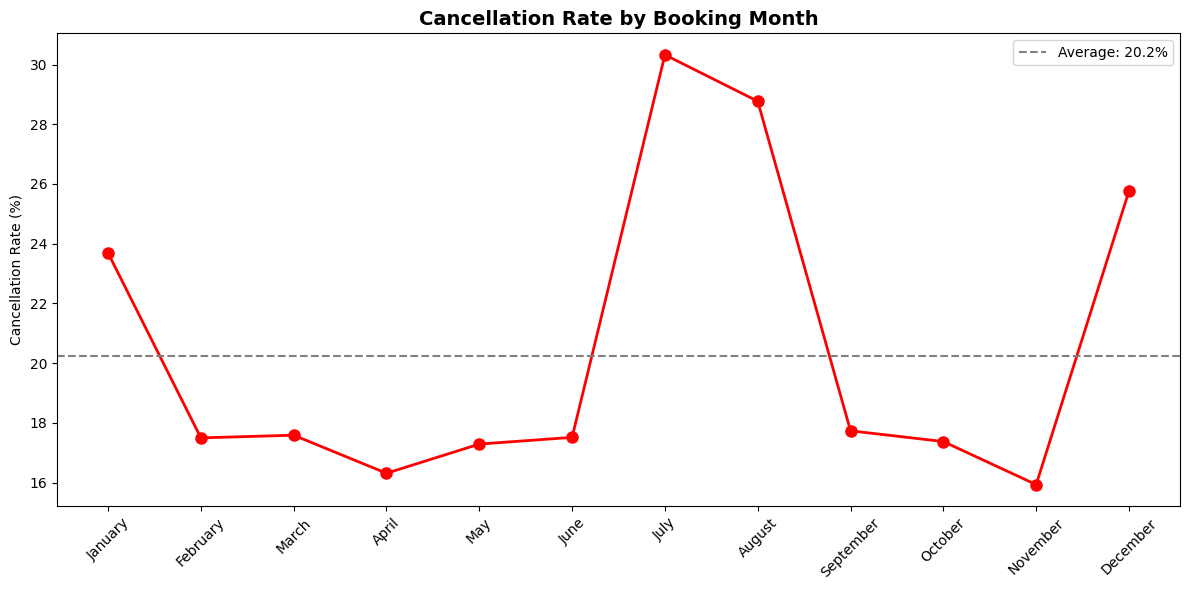


✅ All charts saved:
   - cancellation_analysis_charts.png
   - revenue_analysis.png
   - monthly_trend.png


In [ ]:

# the monthly trend
plt.figure(figsize=(12, 6))
monthly_order = ['January', 'February', 'March', 'April', 'May', 'June',
                 'July', 'August', 'September', 'October', 'November', 'December']
monthly_cancel = df.groupby('booking_month_name')['is_cancelled'].mean() * 100
monthly_cancel = monthly_cancel.reindex(monthly_order)
plt.plot(monthly_order, monthly_cancel.values, marker='o', color='red', linewidth=2, markersize=8)
plt.axhline(y=20.23, color='gray', linestyle='--', label=f'Average: 20.2%')
plt.title('Cancellation Rate by Booking Month', fontsize=14, fontweight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ All charts saved:")
print("   - cancellation_analysis_charts.png")
print("   - revenue_analysis.png")
print("   - monthly_trend.png")